# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

Answers:
1. General linear models are used since they can allow modeling relationships that are not purely linear since they use transformations to handle probabilities, counts, etc. They are better since they do not only work for a straight-line relationship and don't give outputs that don't make sense. 
2. Since logistic regression predicts probabilities. The cross entropy checks how close those probabilities are to the real answers and gives a bigger penalty when its clearly wrong. 
3. True: It still uses a weighted sum of the inputs. The sigmoid just changes the output, not the structure itself.
4. False: It's mainly used for classification, we can map the linear score through the sofmax and pick the class.
5. No: They show change in log-odds, not the actual probability. So it's not a direct change in the output.
6.False: It's still necessary since the model is still a  linear combination of whatever features we feed it. For it to catch more complex patterns, we have to add extra features. 
7. False: It depends on the problem at hand. For classification we would use logistic, and for predicting numbers, we would use linear regression. Using the wrong one can give bad predictions or wrong inferences. 

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [ ]:
import pandas as pd

df = pd.read_csv("./data/data.csv", sep=";")
cols = ["Debtor","Tuition fees up to date","Scholarship holder","Age at enrollment","Curricular units 1st sem (approved)","Target"]
df = df[cols].copy()
print("Missing values in each column:")
print(df.isnull().sum())
df = df.dropna()
df["dropout"] = (df["Target"] == "Dropout").astype(int)
print(df.head())
print(df["dropout"].value_counts())

Missing values in each column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  dropout  
0                                    0   Dropout        1  
1                                    6  Graduate        0  
2                                    0   Dropout        1  
3      

In [3]:
from sklearn.linear_model import LogisticRegression
X =df[["Debtor","Tuition fees up to date","Scholarship holder","Age at enrollment"]]
y = df["dropout"]

log_model= LogisticRegression(max_iter=5000)
log_model.fit(X, y)
coef_df = pd.DataFrame({"Variable":X.columns,"Coefficient":log_model.coef_[0]})
print(coef_df)
print("Intercept:", log_model.intercept_[0])

                  Variable  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925
Intercept: 0.4856926578042171


Variables that increase dropout probability: 
Debtor & Age at enrollment

Variables that decrease dropout probability: 
Tuition fees up to date & Scholarship holder

Thus, being up to date on tuition reduces dropout risk. It has a large negative coefficient rate, meaning it is the most important factor reducing dropout probability in the model. 

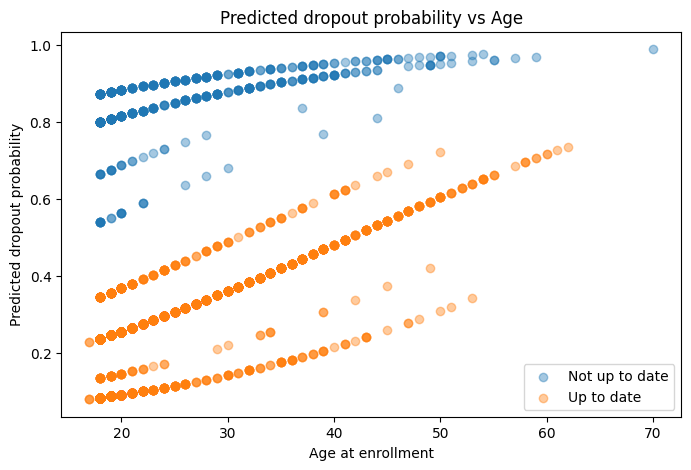

In [ ]:
import matplotlib.pyplot as plt

df["pred_prob"]= log_model.predict_proba(X)[:,1]
plt.figure(figsize=(8,5))
for tuit, label in [(0,"Not up to date"), (1, "Up to date")]:
    sub = df[df["Tuition fees up to date"] == tuit]
    plt.scatter(sub["Age at enrollment"],sub["pred_prob"],alpha=0.4,label=label)
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs Age")
plt.legend()
plt.show()

In [5]:
X_not_up = X.copy()
X_up = X.copy()
X_not_up["Tuition fees up to date"] = 0
X_up["Tuition fees up to date"] = 1
prob_not_up = log_model.predict_proba(X_not_up)[:, 1]
prob_up = log_model.predict_proba(X_up)[:, 1]
avg_change = (prob_up - prob_not_up).mean()

print("Average change in predicted dropout probability when tuition is up to date:")
print(avg_change)

Average change in predicted dropout probability when tuition is up to date:
-0.5161819741732123


In [6]:
df["tuition_effect"] = prob_not_up - prob_up
age_effect = df.groupby("Age at enrollment")["tuition_effect"].mean().sort_values(ascending=False)
print(age_effect.head(10))

Age at enrollment
22    0.537499
23    0.535802
21    0.535541
20    0.532669
24    0.531446
19    0.529255
25    0.527728
26    0.527287
18    0.525951
27    0.524518
Name: tuition_effect, dtype: float64


The up to date points are consistently much lower than the blue points. This means tuition status lowers dropout probability at all ages. However, the largest reduction is around 21-23 years old. This is where tuition status has the strongest impact. The average change is about -0.516 or 51.6 percent points.

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = log_model.predict(X)
cm = confusion_matrix(y, y_pred)
print("Confusion matrix:")
print(cm)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Confusion matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


The model is good at predicting non-dropouts, but it misses many dropouts. It has moderate accuracy (0.76), but it is better at predicting students who stay enrolled vs those who drop out. This means it may under-identify at-risk students. 

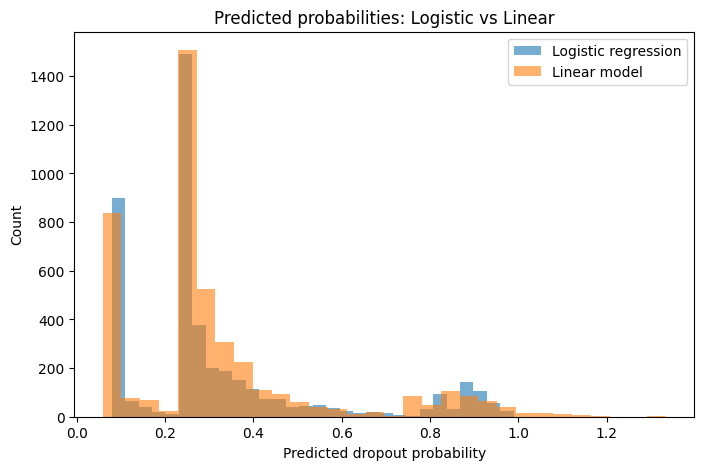

Logistic prediction range: 0.07947078376991204 to 0.9891329873413648
Linear prediction range: 0.05832035022573956 to 1.3349535706758697


In [8]:
from sklearn.linear_model import LinearRegression
lin_model= LinearRegression()
lin_model.fit(X,y)
df["lin_pred"] =lin_model.predict(X)
df["log_pred"] = log_model.predict_proba(X)[:, 1]

plt.figure(figsize=(8,5))
plt.hist(df["log_pred"],bins=30, alpha=0.6, label="Logistic regression")
plt.hist(df["lin_pred"], bins=30, alpha=0.6,label="Linear model")
plt.xlabel("Predicted dropout probability")
plt.ylabel("Count")
plt.title("Predicted probabilities: Logistic vs Linear")
plt.legend()
plt.show()
print("Logistic prediction range:",df["log_pred"].min(), "to", df["log_pred"].max())
print("Linear prediction range:", df["lin_pred"].min(),"to", df["lin_pred"].max())

Logistic regression is better since it keeps predictions between 0 and 1 and has real probabilitites while the linear model has probabilities over 1 and is not valid for classification problems. 

In [9]:
at_risk = df[["Debtor","Tuition fees up to date","Scholarship holder","Age at enrollment","Curricular units 1st sem (approved)","Target","pred_prob"]].sort_values(by="pred_prob", ascending=False)
print(at_risk.head(20))

      Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
689        1                        0                   0                 70   
2876       1                        0                   0                 54   
717        1                        0                   0                 53   
1887       1                        0                   0                 51   
3472       1                        0                   0                 50   
678        1                        0                   0                 50   
709        1                        0                   0                 50   
3526       1                        0                   0                 49   
3281       0                        0                   0                 59   
4260       1                        0                   0                 48   
2407       1                        0                   0                 47   
3074       0                        0   

The highest-risk students are ones who are debtors, not up to date on tuition, those with no scholarship, older at enrollment, and often have 0 approved first-semester courses. To reduce dropout risk, there could be third party factors such as funding from other sources, payment plans, more tutoring, and ways to check in for students who are at-risk.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import pandas as pd

X_multi = df[["Debtor","Tuition fees up to date","Curricular units 1st sem (approved)"]]
y_multi= df["Target"]
multi_model =LogisticRegression(solver="lbfgs",max_iter=5000)
multi_model.fit(X_multi, y_multi)
y_pred_multi= multi_model.predict(X_multi)
cm_multi =confusion_matrix(y_multi, y_pred_multi,labels=multi_model.classes_)

print("Classes:", multi_model.classes_)
print("Confusion matrix:")
print(cm_multi)

Classes: ['Dropout' 'Enrolled' 'Graduate']
Confusion matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


In [12]:
probs = multi_model.predict_proba(X_multi)
prob_df = pd.DataFrame(probs, columns=multi_model.classes_)
print(prob_df.head())

    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104


Hard classification does not predict every class. It predicts dropout and graduate but never enrolled since the .predict() picks the highest probability and enrolled never has the highest. 

On the other hand, predicted probability does include every class since we can see every row has a non-zero value for each of the classes.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [13]:
import pandas as pd

df = pd.read_csv("./data/cirrhosis.csv")
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df =df[cols].copy()
print("Missing values in each column:")
print(df.isnull().sum())

df_survival = df[["Bilirubin","Edema", "Drug", "Status"]].dropna().copy()
df_survival["survived"] = df_survival["Status"].isin(["C","CL"]).astype(int)
print(df_survival.head())
print(df_survival["survived"].value_counts())

df_stage =df[["Bilirubin", "Edema", "Stage"]].dropna().copy()
print(df_stage.head())

Missing values in each column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64
   Bilirubin Edema             Drug Status  survived
0       14.5     Y  D-penicillamine      D         0
1        1.1     N  D-penicillamine      C         1
2        1.4     S  D-penicillamine      D         0
3        1.8     S  D-penicillamine      D         0
4        3.4     N          Placebo     CL         1
survived
1    187
0    125
Name: count, dtype: int64
   Bilirubin Edema  Stage
0       14.5     Y    4.0
1        1.1     N    3.0
2        1.4     S    4.0
3        1.8     S    4.0
4        3.4     N    3.0


In [14]:
from sklearn.linear_model import LogisticRegression
X = pd.get_dummies(df_survival[["Edema","Drug", "Bilirubin"]],drop_first=True)
y = df_survival["survived"]

log_model =LogisticRegression(max_iter=5000)
log_model.fit(X,y)
coef_df = pd.DataFrame({"Variable": X.columns,"Coefficient":log_model.coef_[0]})
print(coef_df)
print("Intercept:", log_model.intercept_[0])

       Variable  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225
Intercept: 1.379827799302292


The drug does not improve survival since the placebo has a positive coefficient, meaning it performs a bit better than the drug. Higher bilirubin leads to lower survival probability. As for the edema effect, S leads to lower survival than no edema while the Y leads to much lower survival. 

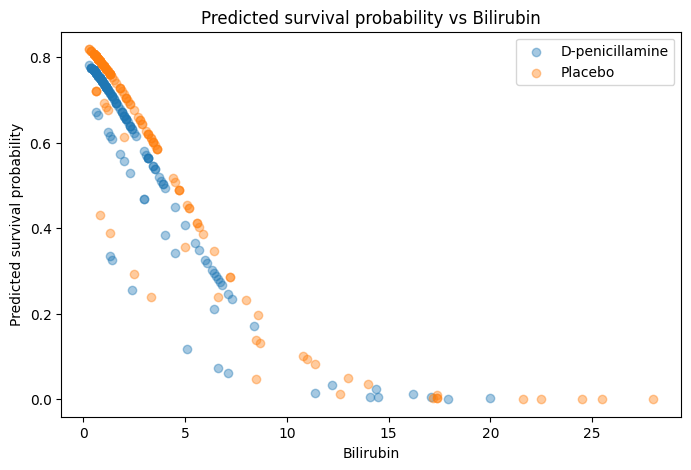

In [15]:
import matplotlib.pyplot as plt
df_survival["pred_prob"] = log_model.predict_proba(X)[:,1]

plt.figure(figsize=(8, 5))
for drug_name in df_survival["Drug"].unique():
    subset = df_survival[df_survival["Drug"] ==drug_name]
    plt.scatter(subset["Bilirubin"],subset["pred_prob"],alpha=0.4,label=drug_name)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs Bilirubin")
plt.legend()
plt.show()

The drug does not improve survival at certain bilirubin levels. The placebo is consistently higher across all of its values.

In [16]:
base = df_survival[["Edema", "Drug", "Bilirubin"]].copy()
drug_version = base.copy()
drug_version["Drug"] = "D-penicillamine"

placebo_version = base.copy()
placebo_version["Drug"] = "Placebo"
X_drug = pd.get_dummies(drug_version, drop_first=True)
X_placebo = pd.get_dummies(placebo_version, drop_first=True)
X_drug = X_drug.reindex(columns=X.columns, fill_value=0)
X_placebo = X_placebo.reindex(columns=X.columns, fill_value=0)
prob_drug = log_model.predict_proba(X_drug)[:, 1]
prob_placebo = log_model.predict_proba(X_placebo)[:, 1]
avg_change = (prob_drug - prob_placebo).mean()
print("Average change in predicted survival probability from taking the drug:")
print(avg_change)

Average change in predicted survival probability from taking the drug:
0.0


There is no average difference between drug and placebo

In [17]:
df_survival["drug_effect"] = prob_drug - prob_placebo
bilirubin_effect = (df_survival.groupby("Bilirubin")["drug_effect"].mean().sort_values(ascending=False))
print(bilirubin_effect.head(10))

Bilirubin
0.3    0.0
0.4    0.0
0.5    0.0
0.6    0.0
0.7    0.0
0.8    0.0
0.9    0.0
1.0    0.0
1.1    0.0
1.2    0.0
Name: drug_effect, dtype: float64


In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = log_model.predict(X)
cm = confusion_matrix(y, y_pred)
print("Confusion matrix:")
print(cm)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Confusion matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


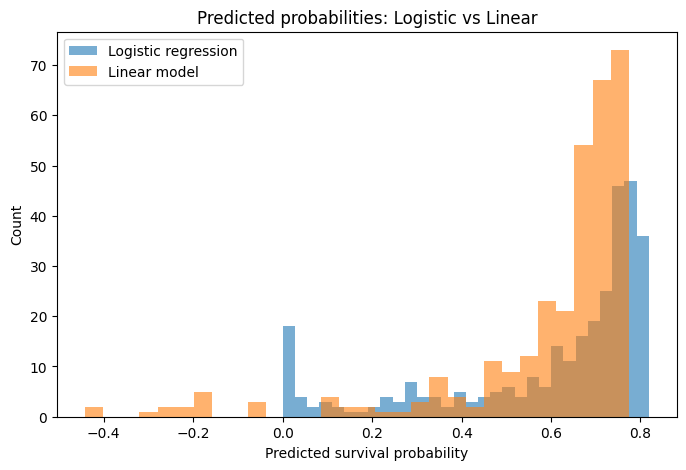

Logistic prediction range: 0.00017000836983990482 to 0.8184120388871091
Linear prediction range: -0.4417396683935991 to 0.7738680250928712


In [19]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)
df_survival["log_pred"] = log_model.predict_proba(X)[:, 1]
df_survival["lin_pred"] = lin_model.predict(X)
plt.figure(figsize=(8, 5))
plt.hist(df_survival["log_pred"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(df_survival["lin_pred"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted survival probability")
plt.ylabel("Count")
plt.title("Predicted probabilities: Logistic vs Linear")
plt.legend()
plt.show()
print("Logistic prediction range:", df_survival["log_pred"].min(), "to", df_survival["log_pred"].max())
print("Linear prediction range:", df_survival["lin_pred"].min(), "to", df_survival["lin_pred"].max())

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_stage = pd.get_dummies(df_stage[["Edema", "Bilirubin"]], drop_first=True)
y_stage = df_stage["Stage"]
stage_model = LogisticRegression(max_iter=5000)
stage_model.fit(X_stage, y_stage)
y_stage_pred = stage_model.predict(X_stage)
cm_stage = confusion_matrix(y_stage, y_stage_pred, labels=stage_model.classes_)
print("Classes:", stage_model.classes_)
print("Confusion matrix:")
print(cm_stage)

Classes: [1. 2. 3. 4.]
Confusion matrix:
[[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 130  25]
 [  0   0  93  51]]


Hard classification does not predict every class, as it only predicts stage 3 and 4. 

In [21]:
stage_probs = stage_model.predict_proba(X_stage)
prob_stage_df = pd.DataFrame(stage_probs, columns=stage_model.classes_)
print(prob_stage_df.head())

        1.0       2.0       3.0       4.0
0  0.000469  0.051111  0.137332  0.811088
1  0.068675  0.255046  0.397581  0.278699
2  0.039844  0.139560  0.340088  0.480508
3  0.035217  0.137518  0.338843  0.488422
4  0.035049  0.243194  0.404019  0.317738


The predicted probabilities do include every class as all 4 stages have values. 

In [22]:
print("Predicted classes from .predict():")
print(pd.Series(y_stage_pred).value_counts().sort_index())

Predicted classes from .predict():
3.0    325
4.0     87
Name: count, dtype: int64


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 